In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/mouadbensalah/high-resolution-load-dataset-from-smart-meters/Marrakech 30T.csv
/kaggle/input/datasets/mouadbensalah/high-resolution-load-dataset-from-smart-meters/Boujdour 10T.csv
/kaggle/input/datasets/mouadbensalah/high-resolution-load-dataset-from-smart-meters/Foum Eloued 10T.csv
/kaggle/input/datasets/mouadbensalah/high-resolution-load-dataset-from-smart-meters/Laayoune 10T.csv


In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, TensorDataset
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

color_pal=sns.color_palette()
plt.style.use('fivethirtyeight')

# Data analyses

In [3]:
dataset=pd.read_csv("/kaggle/input/datasets/mouadbensalah/high-resolution-load-dataset-from-smart-meters/Laayoune 10T.csv", sep=";")

In [4]:
dataset.head()

,DateTime,zone1,zone2,zone3,zone4,zone5
0,14/09/2022 17:10,"73,54","120,92","160,98","122,24","102,92"
1,14/09/2022 17:20,"74,4","122,18","159,4","119,73","101,75"
2,14/09/2022 17:30,"77,89","124,7","159,97","118,51","102,07"
3,14/09/2022 17:40,"78,32","126,73","161,97","118,57","102,91"
4,14/09/2022 17:50,"81,33","125,74","163,19","120,69","102,55"


In [5]:
print(dataset['DateTime'].dtype)

object


In [6]:
print(f"Valeurs nulles : {dataset['zone1'].isna().sum()}")
print(f"Valeurs nulles : {dataset['zone2'].isna().sum()}")
print(f"Valeurs nulles : {dataset['zone3'].isna().sum()}")
print(f"Valeurs nulles : {dataset['zone4'].isna().sum()}")

Valeurs nulles : 0
Valeurs nulles : 0
Valeurs nulles : 0
Valeurs nulles : 0


In [7]:
dataset.index= pd.to_datetime(dataset.index)
dataset.index= pd.to_datetime(dataset.index, format='%d/%m/%Y %H:%M')

In [8]:
print(dataset['DateTime'].dtype)

object


In [9]:
print(f"Valeurs nulles : {dataset['zone1'].isna().sum()}")
print(f"Valeurs nulles : {dataset['zone2'].isna().sum()}")
print(f"Valeurs nulles : {dataset['zone3'].isna().sum()}")
print(f"Valeurs nulles : {dataset['zone4'].isna().sum()}")

Valeurs nulles : 0
Valeurs nulles : 0
Valeurs nulles : 0
Valeurs nulles : 0


In [10]:
dataset=dataset.set_index('DateTime')

In [11]:
dataset=dataset.sort_index()

In [12]:
print(f"Valeurs nulles : {dataset['zone1'].isna().sum()}")
print(f"Valeurs nulles : {dataset['zone2'].isna().sum()}")
print(f"Valeurs nulles : {dataset['zone3'].isna().sum()}")
print(f"Valeurs nulles : {dataset['zone4'].isna().sum()}")

Valeurs nulles : 0
Valeurs nulles : 0
Valeurs nulles : 0
Valeurs nulles : 0


In [13]:
num_cols = dataset.columns
dataset[num_cols] = dataset[num_cols].apply(
    lambda col: pd.to_numeric(
        col.astype(str).str.replace(',', '.', regex=False), 
        errors='coerce'
    )
)

In [14]:
print(f"Valeurs nulles : {dataset['zone1'].isna().sum()}")
print(f"Valeurs nulles : {dataset['zone2'].isna().sum()}")
print(f"Valeurs nulles : {dataset['zone3'].isna().sum()}")
print(f"Valeurs nulles : {dataset['zone4'].isna().sum()}")

Valeurs nulles : 0
Valeurs nulles : 0
Valeurs nulles : 0
Valeurs nulles : 0


<Axes: title={'center': 'Energy Consumption in MW'}, xlabel='DateTime'>

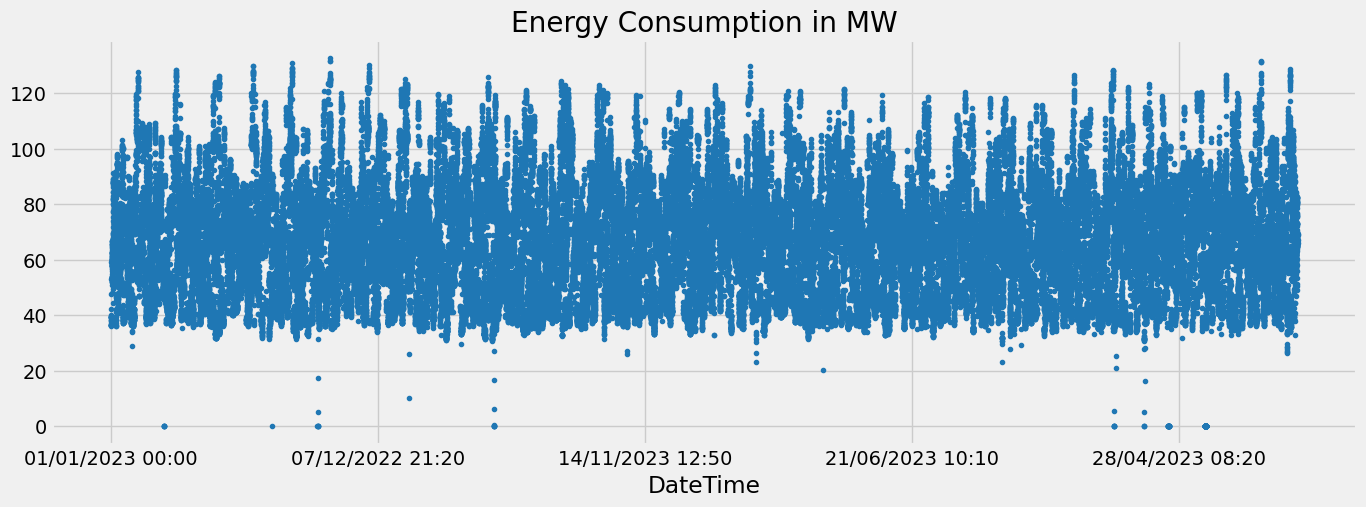

In [15]:
dataset['zone1'].plot(style='.',figsize=(15,5),color=color_pal[0],title='Energy Consumption in MW')

<Axes: title={'center': 'Energy Consumption in MW'}, xlabel='DateTime'>

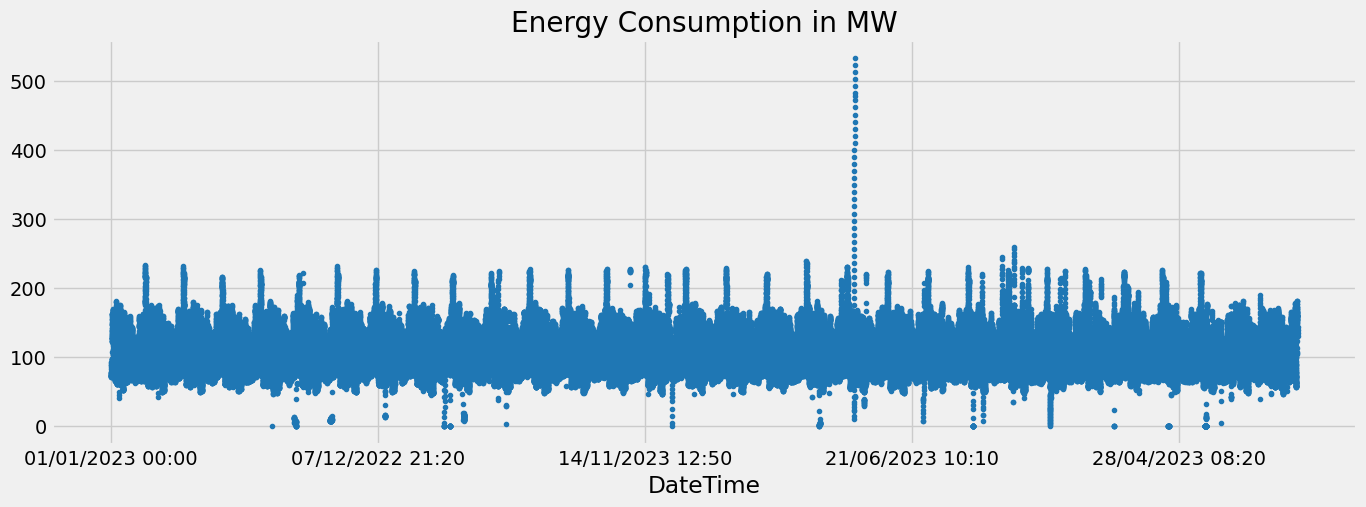

In [16]:
dataset['zone2'].plot(style='.',figsize=(15,5),color=color_pal[0],title='Energy Consumption in MW')

<Axes: title={'center': 'Energy Consumption in MW'}, xlabel='DateTime'>

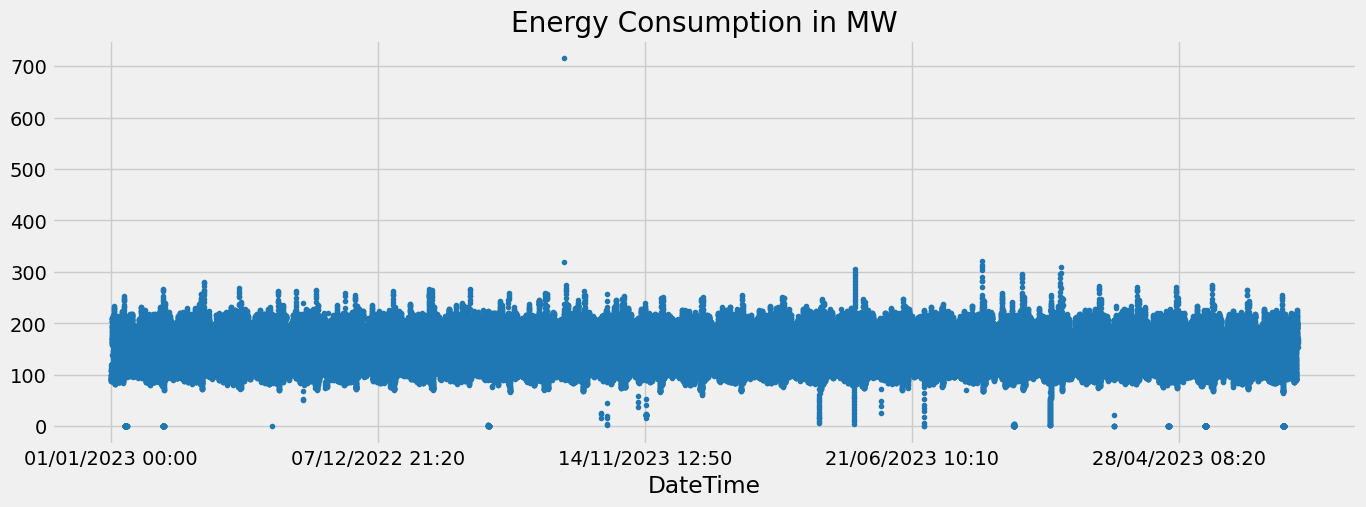

In [17]:
dataset['zone3'].plot(style='.',figsize=(15,5),color=color_pal[0],title='Energy Consumption in MW')

<Axes: title={'center': 'Energy Consumption in MW'}, xlabel='DateTime'>

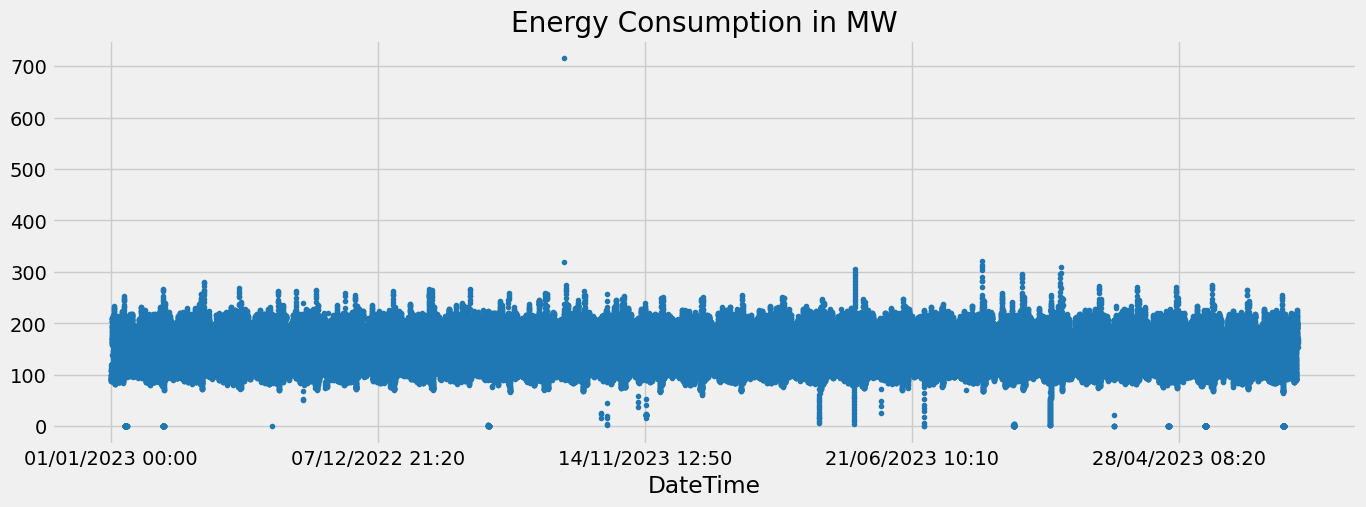

In [18]:
dataset['zone3'].plot(style='.',figsize=(15,5),color=color_pal[0],title='Energy Consumption in MW')

In [19]:
zone_cols = [c for c in dataset.columns if c.startswith('zone')]
dataset['total_load'] = dataset[zone_cols].sum(axis=1)

print(dataset['total_load'].describe())
print(f"Nulls : {dataset['total_load'].isna().sum()}")
print(dataset[['total_load']].head())

count    88890.000000
mean       560.666705
std        131.918830
min          0.000000
25%        448.210000
50%        564.920000
75%        665.460000
max       1316.840000
Name: total_load, dtype: float64
Nulls : 0
                  total_load
DateTime                    
01/01/2023 00:00      442.91
01/01/2023 00:10      426.55
01/01/2023 00:20      418.28
01/01/2023 00:30      409.92
01/01/2023 00:40      403.09


# Reshaping the data for one causal CNN-GAN model

In [20]:

dataset.index= pd.to_datetime(dataset.index, format='%d/%m/%Y %H:%M')

In [21]:
dataset = dataset.resample('1h').mean()

dataset = dataset[dataset['total_load'] > 0]
n_steps=24
for i in range(1, n_steps + 1):
    dataset[f'total_load(t-{i})'] = dataset['total_load'].shift(i)
dataset.dropna(inplace=True)

In [22]:
real_months   = dataset.index.month.values        # 1-12
months_onehot = np.eye(12)[real_months - 1]  # (N, 12)
real_months

array([9, 9, 9, ..., 5, 5, 5], dtype=int32)

In [23]:
months_onehot

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [24]:
raw = dataset.to_numpy()
raw

array([[ 91.35333333, 118.99333333, 166.70333333, ..., 749.82      ,
        624.52833333, 584.64      ],
       [ 95.14833333, 126.50833333, 176.72333333, ..., 745.32833333,
        749.82      , 624.52833333],
       [108.21166667, 152.29833333, 202.33833333, ..., 744.13166667,
        745.32833333, 749.82      ],
       ...,
       [ 78.455     , 144.93833333, 211.87      , ..., 710.40333333,
        719.08833333, 722.99333333],
       [ 87.96333333, 143.21      , 209.445     , ..., 619.2       ,
        710.40333333, 719.08833333],
       [ 87.81      , 141.74      , 212.52      , ..., 522.115     ,
        619.2       , 710.40333333]])

In [25]:
train_size = int(len(raw) * 0.8)
scaler     = MinMaxScaler(feature_range=(-1, 1))
scaler.fit(raw[:train_size])  
normalized = scaler.transform(raw)

In [26]:
y = normalized[:, 0]           # target: t
X = normalized[:, 1:]          # features: t-1 ... t-n_steps
X = np.flip(X, axis=1).copy()  

In [27]:
print("X shape :", X.shape)
print("y shape :", y.shape)
print("n_steps :", n_steps)

X shape : (14778, 29)
y shape : (14778,)
n_steps : 24


In [28]:
n_steps = 24

# Colonnes explicites
lag_cols = [f'total_load(t-{i})' for i in range(1, n_steps + 1)]

X = dataset[lag_cols].values          # (N, 24) 
y = dataset['total_load'].values      # (N,)    

print("X shape :", X.shape)  #  (14778, 24)
print("y shape :", y.shape)  #  (14778,)

split   = int(len(X) * 0.8)
X_train = X[:split].reshape(-1, n_steps, 1)
X_test  = X[split:].reshape(-1, n_steps, 1)
y_train = y[:split].reshape(-1, 1)
y_test  = y[split:].reshape(-1, 1)
months_train = months_onehot[:split]

X shape : (14778, 24)
y shape : (14778,)


In [29]:
months_train[0]

array([0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.])

# Deep learnind models
## GAN model

In [30]:


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class Generator(nn.Module):
    def __init__(self, noise_dim, seq_len, cond_dim, hidden=128):
        super().__init__()
        self.seq_len = seq_len

        self.net = nn.Sequential(
            nn.Linear(noise_dim + cond_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, seq_len)
        )

    def forward(self, z, cond):
        x = torch.cat([z, cond], dim=1)
        return self.net(x)


class Discriminator(nn.Module):
    def __init__(self, seq_len, cond_dim, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.utils.spectral_norm(nn.Linear(seq_len + cond_dim, hidden)),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.utils.spectral_norm(nn.Linear(hidden, hidden)),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.utils.spectral_norm(nn.Linear(hidden, 1))
        )
    def forward(self, seq, cond):
        x = torch.cat([seq, cond], dim=1)
        return self.net(x)


def train_gan(sequences,months,epochs=5,batch_size=64,noise_dim=32,lr=1e-4,):
    
    seq_len = sequences.shape[1]
    cond_dim = months.shape[1]

    G = Generator(noise_dim, seq_len, cond_dim).to(device)
    D = Discriminator(seq_len, cond_dim).to(device)

    opt_G = torch.optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.9))
    opt_D = torch.optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.9))

    loss_fn = nn.BCEWithLogitsLoss()

    X = torch.tensor(sequences, dtype=torch.float32).to(device) #real sequences
    C = torch.tensor(months, dtype=torch.float32).to(device) #conditions

    N = len(X)

    for epoch in range(epochs):

        perm = torch.randperm(N)
        X = X[perm]
        C = C[perm]

        for i in range(0, N, batch_size):

            real_seq = X[i:i+batch_size]
            cond = C[i:i+batch_size]

            if len(real_seq) == 0:
                continue

            z = torch.randn(len(real_seq), noise_dim, device=device)
            fake_seq = G(z, cond).detach()

            real_logits = D(real_seq, cond)
            fake_logits = D(fake_seq, cond)

            d_loss = (
                loss_fn(real_logits, torch.ones_like(real_logits))
                + loss_fn(fake_logits, torch.zeros_like(fake_logits))
            )

            opt_D.zero_grad()
            d_loss.backward()
            opt_D.step()

            z = torch.randn(len(real_seq), noise_dim, device=device)
            fake_seq = G(z, cond)

            fake_logits = D(fake_seq, cond)

            g_loss = loss_fn(fake_logits, torch.ones_like(fake_logits))

            opt_G.zero_grad()
            g_loss.backward()
            opt_G.step()

        print(f"[GAN] epoch={epoch+1}  D={d_loss.item():.4f}  G={g_loss.item():.4f}")

    return G


def generate_synthetic(G, months, n_samples, noise_dim=32):

    cond = torch.tensor(months[:n_samples], dtype=torch.float32).to(device)
    z = torch.randn(n_samples, noise_dim, device=device)

    with torch.no_grad():
        fake = G(z, cond).cpu().numpy()

    return fake


def train_and_generate(sequences,months,n_generate=100,gan_epochs=100):
    n_generate=max(500, len(sequences) // 10)
    if len(sequences) < 2000:
        print("[GAN] skipped (dataset too small)")
        return None, None, False

    G = train_gan(sequences=sequences,months=months,epochs=gan_epochs)

    fake = generate_synthetic(G, months, n_generate)

    y = fake[:, 0:1]
    X = fake[:, 1:]

    print(f"[GAN] ✓ Synthetic generated: {len(X)}")

    return X, y, True


## Causal CNN

In [31]:
class CausalConv1d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation=1):
        super().__init__()
        self.pad  = (kernel_size - 1) * dilation
        self.conv = nn.Conv1d(in_channels, out_channels, kernel_size,
                              padding=0, dilation=dilation)

    def forward(self, x):
        x = nn.functional.pad(x, (self.pad, 0))
        return self.conv(x)


class Net(nn.Module):
    def __init__(self, n_steps=24, num_channels=128, num_layers=2,
                 kernel_size=3, dropout=0.3, input_size=1, hidden_size=None):
        super().__init__()
        C = hidden_size if hidden_size is not None else num_channels
        layers, in_ch = [], 1
        for _ in range(num_layers):
            layers += [CausalConv1d(in_ch, C, kernel_size),
                       nn.BatchNorm1d(C), nn.ReLU(inplace=True)]
            in_ch = C
        layers += [CausalConv1d(in_ch, C, kernel_size=5),
                   nn.BatchNorm1d(C), nn.ReLU(inplace=True)]
        self.conv_net = nn.Sequential(*layers)
        self.dropout  = nn.Dropout(p=dropout)
        self.fc       = nn.Linear(C, 1)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.conv_net(x)
        x = x.mean(dim=-1)
        x = self.dropout(x)
        return self.fc(x)



In [32]:

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        return self.X[i], self.y[i]


In [33]:
batch_size=32
n_steps=24
trainloader = DataLoader(
        TimeSeriesDataset(X_train, y_train),
        batch_size=batch_size,
        shuffle=False,
    )
testloader = DataLoader(
        TimeSeriesDataset(X_test, y_test),
        batch_size=batch_size,
        shuffle=False,
    )

In [34]:
def train(net: nn.Module,trainloader: DataLoader,epochs: int,lr: float,device: torch.device,months_train: np.ndarray = None) -> float:
    net.to(device)
    all_X, all_y = [], []
    for Xb, yb in trainloader:
        all_X.append(Xb.numpy().squeeze(-1))
        all_y.append(yb.numpy())

    
    X_train = np.concatenate(all_X)   
    y_train = np.concatenate(all_y)   
    sequences = np.concatenate([y_train, X_train], axis=1)  

    
    if months_train is not None:
        months = months_train[:len(sequences)]
        print(f"  [GAN] Real months: {sorted(np.unique(np.argmax(months, axis=1)+1))}")
    else:
        print("  [GAN] No real months — using cyclic fallback")
        months = np.tile(np.eye(12),
                         (len(sequences) // 12 + 1, 1))[:len(sequences)]

    
    seq_min, seq_max = sequences.min(), sequences.max()
    sequences_norm = (sequences - seq_min) / (seq_max - seq_min + 1e-8)
    
    X_syn, y_syn, used = train_and_generate(sequences=sequences_norm, months=months)
    
    if used:
        X_syn = X_syn * (seq_max - seq_min) + seq_min
        y_syn = y_syn * (seq_max - seq_min) + seq_min
        print(f"  [GAN] Augmented → {len(X_train):,} samples")
    
    
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
        axes[0].hist(y_train[:len(y_train)-len(y_syn)].flatten(), 
                     bins=40, alpha=0.6, label='Réel', color='#2196F3')
        axes[0].hist(y_syn.flatten(), 
                     bins=40, alpha=0.6, label='Synthétique', color='#FF5722')
        axes[0].set_title('Distribution total_load (réel vs synthétique)')
        axes[0].set_xlabel('Valeur normalisée')
        axes[0].set_ylabel('Fréquence')
        axes[0].legend()
    
        for i in range(min(5, len(X_syn))):
            axes[1].plot(X_syn[i], alpha=0.7, linewidth=1)
        axes[1].set_title('Séquences synthétiques (t-1 → t-24)')
        axes[1].set_xlabel('Lag')
        axes[1].set_ylabel('Valeur normalisée')
    
        plt.tight_layout()
        plt.show()
    
        print(f"  y_syn  : min={y_syn.min():.3f}  max={y_syn.max():.3f}  mean={y_syn.mean():.3f}")
        print(f"  y_réel : min={y_train[:len(y_train)-len(y_syn)].min():.3f}  "
              f"max={y_train[:len(y_train)-len(y_syn)].max():.3f}  "
              f"mean={y_train[:len(y_train)-len(y_syn)].mean():.3f}")
        
    
        trainloader = DataLoader(
            TensorDataset(
                torch.tensor(X_train).unsqueeze(-1).float(),
                torch.tensor(y_train).float()
            ),
            batch_size=trainloader.batch_size,
            shuffle=True,
        )

    net.train()
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(net.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs
    )

    last_loss = 0.0
    for epoch in range(epochs):
        epoch_loss, n_batches = 0.0, 0
        for X_batch, y_batch in trainloader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            optimizer.zero_grad()
            preds = net(X_batch)
            loss  = nn.MSELoss()(preds, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(net.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()
            n_batches  += 1
            if n_batches % 100 == 0:
                print(f"  Epoch {epoch+1}/{epochs}  Batch {n_batches}  "
                      f"Loss {epoch_loss/n_batches:.5f}")

        last_loss = epoch_loss / max(n_batches, 1)
        scheduler.step()
        print(f"  ── Epoch {epoch+1} done  avg_loss={last_loss:.5f}")

    net.load_state_dict(net.state_dict())
    return last_loss



def test(net, testloader, device):
    net.to(device)
    net.eval()

    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in testloader:
            X_batch = X_batch.to(device)
            preds   = net(X_batch).cpu().numpy().flatten()
            labels  = y_batch.cpu().numpy().flatten()
            all_preds.append(preds)
            all_labels.append(labels)

    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_labels)

    avg_mse    = float(np.mean((y_pred - y_true) ** 2))
    avg_mae    = float(np.mean(np.abs(y_pred - y_true)))
    avg_rmse   = float(np.sqrt(avg_mse))
    pseudo_acc = float(np.exp(-avg_mae))  

    mask     = np.abs(y_true) > 1e-6
    avg_mape = (
        float(np.mean(np.abs((y_pred[mask] - y_true[mask]) / y_true[mask])) * 100)
        if mask.sum() > 0 else float('nan')
    )

    ss_res = float(np.sum((y_true - y_pred) ** 2))
    ss_tot = float(np.sum((y_true - np.mean(y_true)) ** 2))
    r2     = float(1.0 - ss_res / ss_tot) if ss_tot > 1e-12 else float('nan')

    sep = "  " + "─" * 44
    print(sep)
    print(f"  Val MSE        : {avg_mse:.6f}")
    print(f"  Val MAE        : {avg_mae:.6f}")
    print(f"  Val RMSE       : {avg_rmse:.6f}")
    print(f"  Val MAPE       : {avg_mape:.2f} %")
    print(f"  Val R²         : {r2:.4f}   (1=perfect, 0=mean-pred)")
    print(f"  Pseudo-Acc     : {pseudo_acc:.4f}   (exp(-MAE))")
    print(sep)

    return avg_mse, avg_mae, pseudo_acc, avg_rmse, avg_mape, r2


  [GAN] Real months: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]
[GAN] epoch=1  D=1.4305  G=0.7251
[GAN] epoch=2  D=1.3972  G=0.7019
[GAN] epoch=3  D=1.3782  G=0.6962
[GAN] epoch=4  D=1.3847  G=0.6957
[GAN] epoch=5  D=1.3925  G=0.6849
[GAN] epoch=6  D=1.3851  G=0.6924
[GAN] epoch=7  D=1.3837  G=0.6824
[GAN] epoch=8  D=1.3853  G=0.6930
[GAN] epoch=9  D=1.3944  G=0.6923
[GAN] epoch=10  D=1.3884  G=0.6928
[GAN] epoch=11  D=1.3835  G=0.6912
[GAN] epoch=12  D=1.3882  G=0.6908
[GAN] epoch=13  D=1.3853  G=0.6931
[GAN] epoch=14  D=1.3849  G=0.6936
[GAN] epoch=15  D=1.3875  G=0.6930
[GAN] epoch=16  D=1.3737  G=0.6950
[GAN] epoch=17  D=1.3854  G=0.6893
[GAN] epoch=18  D=1.3884  G=0.6905
[GAN] epoch=19  D=1.3808  G=0.6946
[GAN] epoch=20  D=1.3868  G=0.6958
[GAN] epoch=21  D=1.3888  G=0.6924
[GAN] epoch=22  D=1.3848  G=0.6952
[GAN] epoch=23  D=1.3819  G=0.6942
[GAN] epoch=24  D=1.386

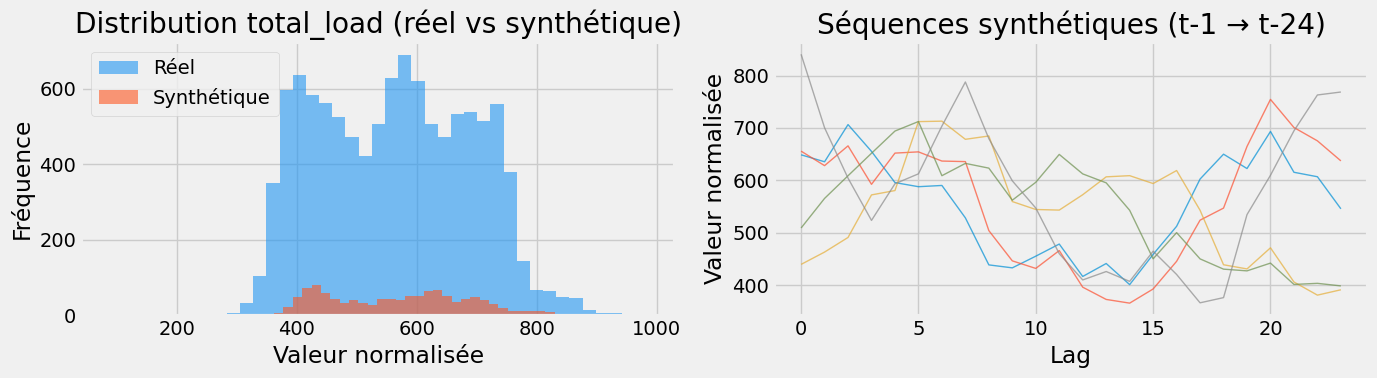

  y_syn  : min=361.947  max=985.306  mean=570.290
  y_réel : min=85.545  max=964.120  mean=562.592
  Epoch 1/10  Batch 100  Loss 326492.60063
  Epoch 1/10  Batch 200  Loss 324988.93281
  Epoch 1/10  Batch 300  Loss 318492.43208
  ── Epoch 1 done  avg_loss=313694.47466
  Epoch 2/10  Batch 100  Loss 275353.60922
  Epoch 2/10  Batch 200  Loss 261752.80711
  Epoch 2/10  Batch 300  Loss 250161.00911
  ── Epoch 2 done  avg_loss=241605.12276
  Epoch 3/10  Batch 100  Loss 183115.11547
  Epoch 3/10  Batch 200  Loss 169732.89574
  Epoch 3/10  Batch 300  Loss 156875.69169
  ── Epoch 3 done  avg_loss=148428.29126
  Epoch 4/10  Batch 100  Loss 93969.65328
  Epoch 4/10  Batch 200  Loss 84083.28488
  Epoch 4/10  Batch 300  Loss 75124.00622
  ── Epoch 4 done  avg_loss=69096.84304
  Epoch 5/10  Batch 100  Loss 34378.45020
  Epoch 5/10  Batch 200  Loss 29136.82739
  Epoch 5/10  Batch 300  Loss 24919.43711
  ── Epoch 5 done  avg_loss=22493.67039
  Epoch 6/10  Batch 100  Loss 8519.53780
  Epoch 6/10  Batc

In [35]:
model=Net()
loss = train(model, trainloader, epochs=10, lr=0.001, device=device,months_train=months_train)
mse, mae, acc, rmse, mape, r2 = test(model, testloader, device)